# Glioblastoma-specific super-enhancer AAV cassette

This notebook builds an annotated in-silico AAV transfer cassette inspired by the synthetic super-enhancer gene-therapy construct from the Nature article on precision viral immunotherapy. The goal is not to design a wet-lab production protocol; the goal is to create a biologically plausible sequence context for testing expression-prediction models.

We want to test two related hypotheses:

1. A model that receives the full sequence context containing the glioblastoma-associated synthetic super-enhancer should predict high expression in glioblastoma-like conditions and low expression in unrelated cell types.
2. A model trained or specialized on glioblastoma regulatory data should perform better on this construct than a less context-matched model, because the strongest regulatory information comes from glioblastoma-specific enhancer activity.

The assembled cassette follows this conceptual layout:

```text
AAV ITR - synthetic super-enhancer - minimal CMV promoter - Kozak - HSV-TK - P2A - mouse IL-12 fusion - bGH polyA - AAV ITR
```

In the original article, AAV1 describes the capsid used for delivery. The sequence assembled here is the transfer cassette placed between AAV inverted terminal repeats, so AAV1 is treated as delivery metadata rather than as a coding part of the construct.


In [1]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from gena_expression.conditions import Condition, DescriptionLookup
from gena_expression.genome import Genome
from gena_expression.models import SequenceModel
from gena_expression.sequences import AnnotatedSequence, Feature, CoordinateMap

In [2]:
# Paths and constants used by later cells
GENA_LM_ROOT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark") / "GENA_LM" # CHANGE THIS LINE

EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_CLS = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_CLS}::ExpressionCounts"

MODEL_CHECKPOINT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark") / "models" / "expression_model" / "pytorch_model.bin" # CHANGE THIS LINE
MODEL_CONFIG = EXPRESSION_TASK_DIR / "inference_example_config.yaml" # CHANGE THIS LINE
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

#DATA_DIR = Path("../data").resolve()
DATA_DIR = Path("/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data").resolve()
#DESCRIPTION_DIR = DATA_DIR / "real_descriptions"
DESCRIPTION_DIR = DATA_DIR / "metadata"

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa") # CHANGE THIS LINE
GENOME_ANNOTATION = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
) # CHANGE THIS LINE

DEVICE = "cuda:5"
os.environ["GENALM_HOME"] = Path('../../../../..').resolve().__str__() # CHANGE THIS LINE

In [3]:
import random

def random_dna_sequence(n: int, seed: int | None = None) -> AnnotatedSequence:
    rng = random.Random(seed)
    return AnnotatedSequence(sequence="".join(rng.choice("ACGT") for _ in range(n)), name='random spacer')

In [4]:
random_dna_sequence(10, seed=42)

AnnotatedSequence(sequence='AAGCCCAATA', name='random spacer', features=(), coordinate_map=CoordinateMap(segments=(CoordinateSegment(seq_start=0, seq_end=10, source='sequence', chrom=None, source_start=0, source_end=10, strand=None, metadata=None),)), metadata={})

## Minimal CMV promoter

This section extracts the minimal CMV promoter from a SnapGene plasmid map. A minimal promoter supplies the core transcription-initiation machinery but has weak activity by itself; it is designed to become active when an upstream enhancer recruits the right transcription factors.

In the original article, synthetic super-enhancers were placed upstream of a minimal CMV promoter so that enhancer activity, rather than a strong constitutive promoter, controlled transgene expression. For our model benchmark, this is useful because the prediction should mostly depend on whether the upstream glioblastoma super-enhancer is recognized as active in the tested cell type.


In [5]:
"""Convert SnapGene .dna files to variant_api AnnotatedSequence objects.

Use this as a standalone helper:

    from snapgene_to_annotated_sequence import snapgene_to_annotated_sequence

    seq = snapgene_to_annotated_sequence("plasmid.dna")

The module expects ``variant_api`` to be importable, because it returns the
``AnnotatedSequence`` class defined in ``variant_api.sequences``.
"""

from __future__ import annotations

import re
from pathlib import Path
from typing import Any, Iterable, Mapping, Sequence
from xml.etree import ElementTree


_SNAPGENE_COOKIE_PACKET = 0x09
_SNAPGENE_DNA_PACKET = 0x00
_SNAPGENE_PRIMERS_PACKET = 0x05
_SNAPGENE_NOTES_PACKET = 0x06
_SNAPGENE_FEATURES_PACKET = 0x0A


def snapgene_to_annotated_sequence(
    path: str | Path,
    *,
    name: str | None = None,
    include_primers: bool = True,
) -> AnnotatedSequence:
    """Read a SnapGene ``.dna`` file as an ``AnnotatedSequence``.

    SnapGene stores records as binary packets. This parser handles the core
    packets needed for annotation-preserving workflows: DNA bases, notes,
    sequence features, and primer binding sites. Coordinates are converted from
    SnapGene's 1-based inclusive ranges to 0-based half-open feature intervals.

    Multi-segment and circular-origin-spanning annotations are emitted as
    separate linked ``Feature`` rows because ``Feature`` represents one
    interval.
    """

    path = Path(path)
    packets = list(_iter_snapgene_packets(path.read_bytes()))
    if not packets:
        raise ValueError(f"SnapGene file is empty: {path}")

    packet_type, cookie = packets[0]
    if packet_type != _SNAPGENE_COOKIE_PACKET:
        raise ValueError("SnapGene file does not start with a cookie packet.")
    _validate_snapgene_cookie(cookie)

    sequence: str | None = None
    dna_flags: int | None = None
    notes: dict[str, str] = {}
    for packet_type, data in packets[1:]:
        if packet_type == _SNAPGENE_DNA_PACKET:
            if sequence is not None:
                raise ValueError("SnapGene file contains more than one DNA packet.")
            if not data:
                raise ValueError("SnapGene DNA packet is empty.")
            dna_flags = data[0]
            sequence = data[1:].decode("ascii")
        elif packet_type == _SNAPGENE_NOTES_PACKET:
            notes.update(_parse_snapgene_notes(data))

    if sequence is None:
        raise ValueError("SnapGene file does not contain a DNA packet.")

    features: list[Feature] = []
    for packet_type, data in packets[1:]:
        if packet_type == _SNAPGENE_FEATURES_PACKET:
            features.extend(_parse_snapgene_features(data, len(sequence)))
        elif include_primers and packet_type == _SNAPGENE_PRIMERS_PACKET:
            features.extend(_parse_snapgene_primers(data, len(sequence)))

    sequence_name = name or _snapgene_record_name(notes) or path.stem
    topology = "circular" if (dna_flags or 0) & 0x01 else "linear"
    metadata = {
        "source_format": "snapgene",
        "source_path": str(path),
        "topology": topology,
        "snapgene_flags": dna_flags,
        "snapgene_notes": notes,
    }
    return AnnotatedSequence(
        sequence,
        name=sequence_name,
        features=features,
        coordinate_map=CoordinateMap.from_length(len(sequence), source=str(path)),
        metadata=metadata,
    )


def _iter_snapgene_packets(data: bytes) -> Iterable[tuple[int, bytes]]:
    offset = 0
    while offset < len(data):
        if offset + 5 > len(data):
            raise ValueError("Unexpected end of SnapGene packet header.")
        packet_type = data[offset]
        length = int.from_bytes(data[offset + 1 : offset + 5], "big")
        offset += 5
        packet_data = data[offset : offset + length]
        if len(packet_data) != length:
            raise ValueError("Unexpected end of SnapGene packet data.")
        offset += length
        yield packet_type, packet_data


def _validate_snapgene_cookie(data: bytes) -> None:
    if len(data) < 8 or data[:8].decode("ascii", errors="replace") != "SnapGene":
        raise ValueError("The file is not a valid SnapGene file.")


def _parse_snapgene_notes(data: bytes) -> dict[str, str]:
    root = _parse_snapgene_xml(data)
    notes: dict[str, str] = {}
    for child in root:
        value = _decode_snapgene_text("".join(child.itertext()).strip())
        if value:
            notes[child.tag] = value
    return notes


def _parse_snapgene_features(data: bytes, sequence_length: int) -> list[Feature]:
    root = _parse_snapgene_xml(data)
    features: list[Feature] = []
    for feature_index, feature_node in enumerate(root.findall(".//Feature"), start=1):
        feature_type = _snapgene_attr(feature_node, "type", default="misc_feature")
        feature_name = _snapgene_attr(feature_node, "name")
        directionality = _snapgene_attr(feature_node, "directionality")
        strand = _snapgene_feature_strand(directionality)
        qualifiers = _parse_snapgene_qualifiers(feature_node)
        segments = [
            segment
            for segment in feature_node.findall("Segment")
            if _snapgene_attr(segment, "type", default="standard") != "gap"
        ]
        if not segments:
            raise ValueError(f"SnapGene feature {feature_name or feature_index!r} has no location segment.")

        for segment_index, segment in enumerate(segments, start=1):
            range_spec = _snapgene_attr(segment, "range", required=True)
            assert range_spec is not None
            segment_name = _snapgene_attr(segment, "name")
            intervals = _snapgene_range_to_intervals(range_spec, sequence_length)
            if not intervals:
                continue
            display_name = _snapgene_feature_name(
                feature_name=feature_name,
                segment_name=segment_name,
                qualifiers=qualifiers,
                feature_type=feature_type,
            )
            for interval_index, (start, end) in enumerate(intervals, start=1):
                features.append(
                    Feature(
                        name=display_name,
                        start=start,
                        end=end,
                        type=feature_type,
                        strand=strand,
                        source="snapgene",
                        metadata=_snapgene_feature_metadata(
                            feature_index=feature_index,
                            feature_name=feature_name,
                            segment_index=segment_index,
                            segment_count=len(segments),
                            segment_name=segment_name,
                            interval_index=interval_index,
                            interval_count=len(intervals),
                            range_spec=range_spec,
                            qualifiers=qualifiers,
                            extra={
                                "directionality": directionality,
                                "color": _snapgene_attr(feature_node, "color"),
                            },
                        ),
                    )
                )
    return features


def _parse_snapgene_primers(data: bytes, sequence_length: int) -> list[Feature]:
    root = _parse_snapgene_xml(data)
    features: list[Feature] = []
    min_match_length = 0
    min_melting_temperature = 0
    for params in root.findall(".//HybridizationParams"):
        min_match_length = _snapgene_int_attr(params, "minContinuousMatchLen", default=0)
        min_melting_temperature = _snapgene_int_attr(params, "minMeltingTemperature", default=0)

    for primer_index, primer in enumerate(root.findall(".//Primer"), start=1):
        primer_name = _snapgene_attr(primer, "name") or f"primer_{primer_index}"
        seen_simplified_sites: set[tuple[int, int, str]] = set()
        binding_sites = primer.findall("BindingSite")
        for site_index, site in enumerate(binding_sites, start=1):
            annealed_bases = _snapgene_attr(site, "annealedBases")
            if annealed_bases is not None and len(annealed_bases) < min_match_length:
                continue
            melting_temperature = _snapgene_attr(site, "meltingTemperature")
            if melting_temperature is not None and int(float(melting_temperature)) < min_melting_temperature:
                continue

            range_spec = _snapgene_attr(site, "location", required=True)
            assert range_spec is not None
            strand = "-" if _snapgene_attr(site, "boundStrand", default="0") == "1" else "+"
            intervals = _snapgene_range_to_intervals(range_spec, sequence_length, primer=True)
            for interval_index, (start, end) in enumerate(intervals, start=1):
                site_key = (start, end, strand)
                simplified = _snapgene_attr(site, "simplified", default="0") == "1"
                if simplified and site_key in seen_simplified_sites:
                    continue
                seen_simplified_sites.add(site_key)
                features.append(
                    Feature(
                        name=primer_name,
                        start=start,
                        end=end,
                        type="primer_bind",
                        strand=strand,
                        source="snapgene",
                        metadata={
                            "source_format": "snapgene",
                            "primer_index": primer_index,
                            "site_index": site_index,
                            "site_count": len(binding_sites),
                            "interval_index": interval_index,
                            "interval_count": len(intervals),
                            "range": range_spec,
                            "annealed_bases": annealed_bases,
                            "melting_temperature": melting_temperature,
                            "simplified": simplified,
                        },
                    )
                )
    return features


def _parse_snapgene_xml(data: bytes) -> ElementTree.Element:
    try:
        return ElementTree.fromstring(data.decode("utf-8"))
    except ElementTree.ParseError as exc:
        raise ValueError(f"Could not parse SnapGene XML packet: {exc}") from exc


def _snapgene_attr(
    node: ElementTree.Element,
    name: str,
    *,
    default: str | None = None,
    required: bool = False,
) -> str | None:
    if name in node.attrib:
        return _decode_snapgene_text(node.attrib[name])
    if required:
        raise ValueError(f"Missing SnapGene XML attribute {name!r}.")
    return default


def _snapgene_int_attr(node: ElementTree.Element, name: str, *, default: int = 0) -> int:
    value = _snapgene_attr(node, name)
    return default if value is None else int(value)


def _decode_snapgene_text(text: str) -> str:
    text = re.sub(r"<[^>]+>", "", text)
    return re.sub(r"\r\n|\r|\n", " ", text).strip()


def _parse_snapgene_qualifiers(feature_node: ElementTree.Element) -> dict[str, list[Any]]:
    qualifiers: dict[str, list[Any]] = {}
    for qualifier in feature_node.findall("Q"):
        name = _snapgene_attr(qualifier, "name", required=True)
        assert name is not None
        values: list[Any] = []
        for value_node in qualifier.findall("V"):
            if "text" in value_node.attrib:
                values.append(_decode_snapgene_text(value_node.attrib["text"]))
            elif "predef" in value_node.attrib:
                values.append(_decode_snapgene_text(value_node.attrib["predef"]))
            elif "int" in value_node.attrib:
                values.append(int(value_node.attrib["int"]))
        qualifiers[name] = values
    return qualifiers


def _snapgene_feature_name(
    *,
    feature_name: str | None,
    segment_name: str | None,
    qualifiers: Mapping[str, Sequence[Any]],
    feature_type: str,
) -> str:
    for key in ("label", "gene", "product", "note"):
        values = qualifiers.get(key)
        if values:
            return str(values[0])
    return feature_name or segment_name or feature_type or "feature"


def _snapgene_feature_strand(directionality: str | None) -> str | None:
    if directionality == "1":
        return "+"
    if directionality == "2":
        return "-"
    return None


def _snapgene_range_to_intervals(
    range_spec: str,
    sequence_length: int,
    *,
    primer: bool = False,
) -> list[tuple[int, int]]:
    try:
        left, right = (int(value) for value in range_spec.split("-", 1))
    except ValueError as exc:
        raise ValueError(f"Could not parse SnapGene feature range {range_spec!r}.") from exc

    start = left - 1
    end = right
    if primer:
        start += 1
        end += 1

    raw_intervals = [(start, sequence_length), (0, end)] if start >= end else [(start, end)]
    intervals: list[tuple[int, int]] = []
    for raw_start, raw_end in raw_intervals:
        clipped_start = max(0, min(sequence_length, raw_start))
        clipped_end = max(0, min(sequence_length, raw_end))
        if clipped_end > clipped_start:
            intervals.append((clipped_start, clipped_end))
    return intervals


def _snapgene_feature_metadata(
    *,
    feature_index: int,
    feature_name: str | None,
    segment_index: int,
    segment_count: int,
    segment_name: str | None,
    interval_index: int,
    interval_count: int,
    range_spec: str,
    qualifiers: Mapping[str, Sequence[Any]],
    extra: Mapping[str, Any],
) -> dict[str, Any]:
    metadata: dict[str, Any] = {
        "source_format": "snapgene",
        "feature_index": feature_index,
        "feature_name": feature_name,
        "segment_index": segment_index,
        "segment_count": segment_count,
        "segment_name": segment_name,
        "interval_index": interval_index,
        "interval_count": interval_count,
        "range": range_spec,
        "qualifiers": dict(qualifiers),
    }
    metadata.update({key: value for key, value in extra.items() if value is not None})
    return metadata


def _snapgene_record_name(notes: Mapping[str, str]) -> str | None:
    for key in ("Name", "SequenceName", "AccessionNumber"):
        value = notes.get(key)
        if value:
            return value
    comments = notes.get("Comments")
    return comments.split(" ", 1)[0] if comments else None


In [6]:
cmv_promoter_dna_path = '/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids/snapgene/CMV_promoter.dna'

In [7]:
cmv_promoter = snapgene_to_annotated_sequence(cmv_promoter_dna_path)

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'CMV_promoter'}, xlabel='Sequence coordinate'>)

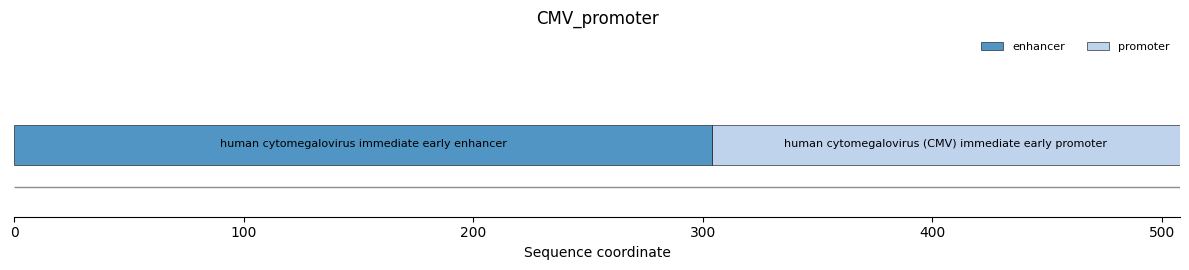

In [8]:
cmv_promoter.plot_annotations()

In [9]:
MINIMAL_CMV_PROMOTER = cmv_promoter.select('early promoter')

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'human cytomegalovirus (CMV) immediate early promoter'}, xlabel='Sequence coordinate'>)

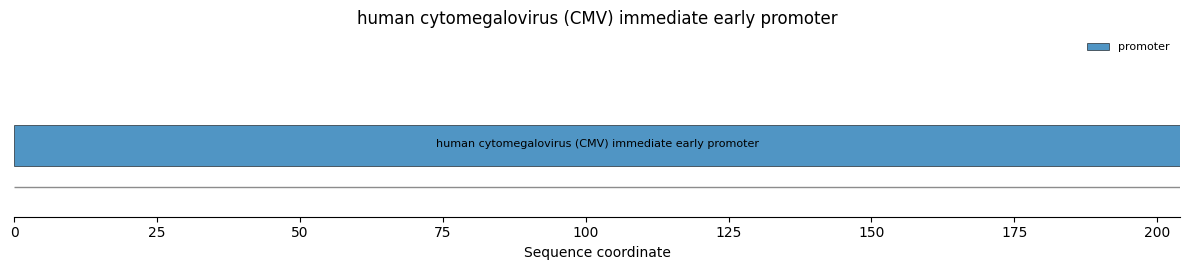

In [10]:
MINIMAL_CMV_PROMOTER.plot_annotations()

In [11]:
MINIMAL_CMV_PROMOTER = AnnotatedSequence(MINIMAL_CMV_PROMOTER.sequence, name='minimal CMV promoter', features=(Feature(name='minimal\nCMV\npromoter', start=0, end=204, type='promoter', strand='+', source='snapgene', metadata={'source_format': 'snapgene', 'feature_index': 1, 'feature_name': 'CMV promoter', 'segment_index': 1, 'segment_count': 1, 'segment_name': None, 'interval_index': 1, 'interval_count': 1, 'range': '305-508', 'qualifiers': {'note': ['human cytomegalovirus (CMV) immediate early promoter']}, 'directionality': '1'}),))

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'minimal CMV promoter'}, xlabel='Sequence coordinate'>)

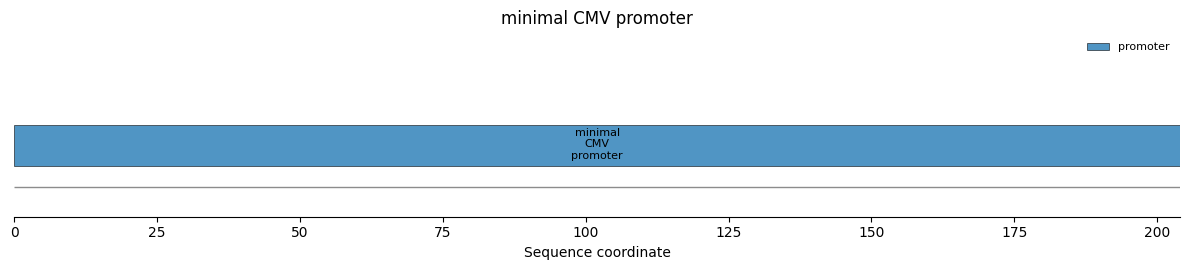

In [12]:
MINIMAL_CMV_PROMOTER.plot_annotations()

## AAV inverted terminal repeats

This section obtains the left and right AAV inverted terminal repeats (ITRs).

ITRs are the cis elements that flank a recombinant AAV transfer genome. They are needed for AAV genome packaging and replication in a real vector system, while the AAV1 serotype from the article refers to the capsid used for delivery. For expression prediction, the ITRs provide full vector context, but the main regulatory signal should come from the enhancer-promoter region.


In [13]:
from gena_expression.plasmids import PlasmidRecord

In [14]:
aav_record = PlasmidRecord.from_ncbi(ncbi_url='https://www.ncbi.nlm.nih.gov/nuccore/J01901.1', data_storage='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids', reporter_feature_name='')

In [15]:
aav_annotated_sequence = aav_record.annotated_sequence()

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'AA2CG'}, xlabel='Sequence coordinate'>)

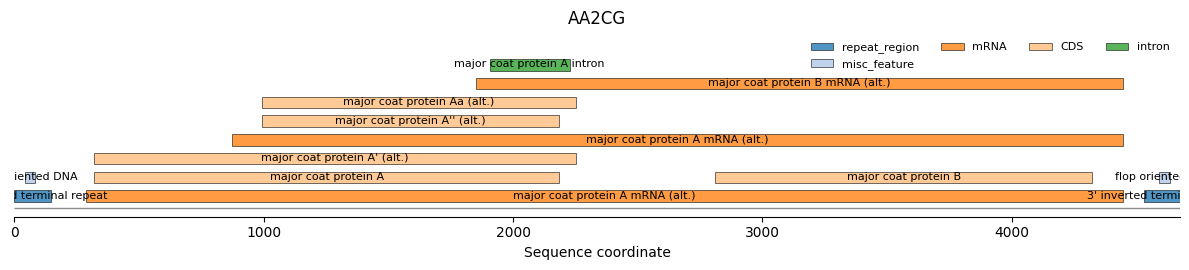

In [16]:
aav_annotated_sequence.plot_annotations()

In [17]:
LEFT_ITR = AnnotatedSequence(sequence=aav_annotated_sequence.select(feature = "5' inverted terminal repeat").sequence,
                                name="5'-ITR", features=[
                                                            Feature(name="5'-ITR", 
                                                                    start=0, 
                                                                    end=aav_annotated_sequence.select(feature = "5' inverted terminal repeat").sequence.__len__(),
                                                                    type='ITR')
                                                        ]
                            )
RIGHT_ITR = AnnotatedSequence(sequence=aav_annotated_sequence.select(feature = "3' inverted terminal repeat").sequence,
                                name="3'-ITR", features=[
                                                            Feature(name="3'-ITR", 
                                                                    start=0, 
                                                                    end=aav_annotated_sequence.select(feature = "3' inverted terminal repeat").sequence.__len__(),
                                                                    type='ITR')
                                                        ]
                            )

## Synthetic super-enhancer

This section defines the synthetic super-enhancer sequence by concatenating four enhancer fragments: `ID4310`, `ID4428`, `ID0785`, and `ID3836`.

Each fragment is a short glioblastoma-associated regulatory element from the article's enhancer library. Together they form the synthetic super-enhancer referred to as `SSE-7`. In the original article, this super-enhancer was used to drive tumor-selective expression from a minimal promoter. In this notebook, it is the central test element: a glioblastoma-aware expression model should assign high activity to this sequence in glioblastoma-like contexts and lower activity elsewhere.


In [18]:
enhancer_seqs = {
    "ID4310": (
        "TTGTCCTGCCTTTGAGAACACTGGAAGGGCACTGAAGGCTGACCAGCATGCACCTCACCCCACCTCCTCTCTGTCTCATCCTCAGCCATC"
        "TAAGCGGGAGACTCATCAGGCTTAAATTCTCATTCTTATCCAAGATTCTTCTGCTTCAAATGAG"
    ),
    "ID4428": (
        "TCTAAATGGAGATCCTCCCATAAAGGGAGTTCTGTTTGGGCTTCCCTTGGAAGTCCATTGAAAGCGTTTCACATTTCAATGCTTCTTTACAT"
        "TCTCCTCTAGAATGAATCTGGAAGGGCCATTTCATTCCAGCCCTATCAGATTTACTACTTCCTCCTGT"
    ),
    "ID0785": (
        "AAGAATGAACTGGGCCCAGCTGGGCATTTGCATCAAAGTGCCTCACCAGAGTTCCCAGCTGCTCTGGCAGAGTGCCCAGGCTTGCCCCA"
        "GAGCCCAAACAGAATGCTCTTTGAGATGCCTCTGGTTTTCA"
    ),
    "ID3836": (
        "TACCCTTCCAGGGGAGCAGTTTCCTGGCTGTGTCGTCAGATACTGTGGTTTACGCTGTTCCGGAGTCTGGAGGTCTGTGTGCCTTTGATC"
        "TCTTTCCCAACTAATTTGCACAGCTGCTGTGGAGGCCCTCATGAATGACCTCTTTCTTTCCTTTCT"
    ),
}

In [19]:
enhancers = [AnnotatedSequence(sequence=seq, name=enhancer, features=[Feature(start=0, end=len(seq), name=enhancer, type='enhancer')]) for enhancer, seq in enhancer_seqs.items()]

In [20]:
enhancers_with_spacers = [enhancers[i//2] if i % 2==0 else random_dna_sequence(20, seed=42) for i in range(len(enhancers)*2)]

In [21]:
enhancers_with_spacers

[AnnotatedSequence(sequence='TTGTCCTGCCTTTGAGAACACTGGAAGGGCACTGAAGGCTGACCAGCATGCACCTCACCCCACCTCCTCTCTGTCTCATCCTCAGCCATCTAAGCGGGAGACTCATCAGGCTTAAATTCTCATTCTTATCCAAGATTCTTCTGCTTCAAATGAG', name='ID4310', features=(Feature(name='ID4310', start=0, end=154, type='enhancer', strand=None, source=None, metadata=None),), coordinate_map=CoordinateMap(segments=(CoordinateSegment(seq_start=0, seq_end=154, source='sequence', chrom=None, source_start=0, source_end=154, strand=None, metadata=None),)), metadata={}),
 AnnotatedSequence(sequence='AAGCCCAATAAACCACTCTG', name='random spacer', features=(), coordinate_map=CoordinateMap(segments=(CoordinateSegment(seq_start=0, seq_end=20, source='sequence', chrom=None, source_start=0, source_end=20, strand=None, metadata=None),)), metadata={}),
 AnnotatedSequence(sequence='TCTAAATGGAGATCCTCCCATAAAGGGAGTTCTGTTTGGGCTTCCCTTGGAAGTCCATTGAAAGCGTTTCACATTTCAATGCTTCTTTACATTCTCCTCTAGAATGAATCTGGAAGGGCCATTTCATTCCAGCCCTATCAGATTTACTACTTCCTCCTGT', name='ID4428', features=(F

In [22]:
SUPER_ENCHANCER = AnnotatedSequence.concat(*enhancers_with_spacers)

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'Annotated sequence'}, xlabel='Sequence coordinate'>)

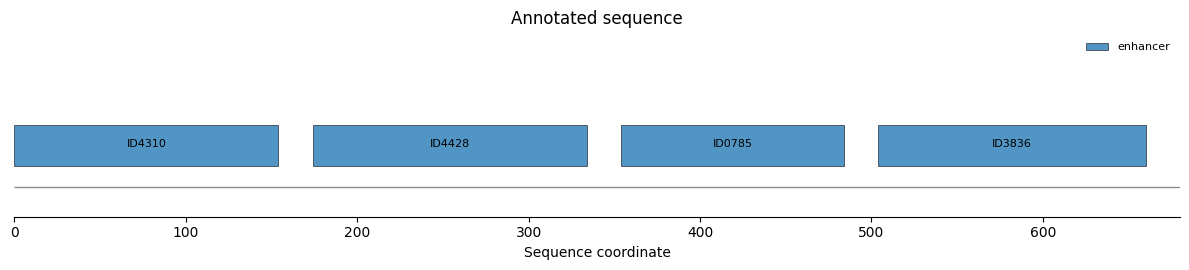

In [23]:
SUPER_ENCHANCER.plot_annotations()

## HSV-TK coding sequence

This section retrieves the HSV-1 `UL23` thymidine kinase coding sequence. HSV-TK is a suicide/prodrug-activating enzyme: in a therapeutic setting it can convert nucleoside analog prodrugs such as ganciclovir into toxic metabolites in expressing cells.

In the original article, HSV-TK was used as the toxic effector payload downstream of the glioblastoma super-enhancer. For the in-silico benchmark, the important point is that this is the first protein-coding payload after the enhancer-promoter module. Because HSV-TK is followed by P2A and another CDS, its stop codon should be removed before fusion.


In [24]:
human_herpesvirus_1_record = PlasmidRecord.from_ncbi(ncbi_url='https://www.ncbi.nlm.nih.gov/nuccore/NC_001806.2', data_storage='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids', reporter_feature_name='')

In [25]:
UL23_TK_CDS = (
    human_herpesvirus_1_record
    .annotated_sequence()
    .select(start=46672, end=47803, strand='-')[:-3]  # remove stop codon before P2A
)


(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'NC_001806'}, xlabel='Sequence coordinate'>)

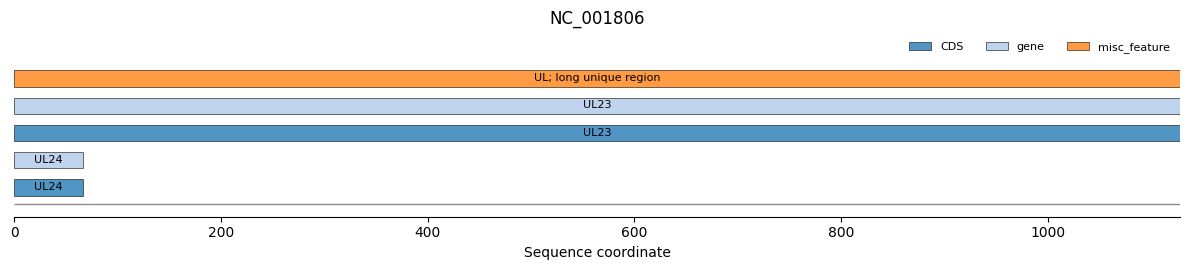

In [26]:
UL23_TK_CDS.plot_annotations()

## Kozak sequence and P2A peptide

This section adds two short synthetic expression-design elements.

The Kozak sequence (`GCCACC`) is placed immediately before the HSV-TK start codon to provide a strong mammalian translation-initiation context. It is not taken from HSV-TK itself; it is a standard vector-design addition.

P2A is a short ribosome-skipping peptide derived from porcine teschovirus 1. It allows one mRNA and one open reading frame to produce two protein products: HSV-TK upstream of P2A and the mouse IL-12 fusion downstream of P2A. In the original article, this layout allowed the same enhancer-promoter cassette to co-express the toxic HSV-TK payload and the immune-activating IL-12 payload.


In [27]:
KOZAK = AnnotatedSequence("GCCACC", name='Kozak')

In [28]:
P2A_dna = (
    "GGCTCTGGAGCCACCAACTTCAGCCTGCTGAAGCAGGCT"
    "GGAGACGTGGAGGAGAACCCTGGACCT"
)

In [29]:
P2A = AnnotatedSequence(P2A_dna, name='P2A', features=[Feature(name='P2A', start=0, end=P2A_dna.__len__(), type='P2A_protein')])

## Mouse IL-12 fusion

This section retrieves the mouse IL-12 subunits: `Il12b` encodes p40 and `Il12a` encodes p35. Native IL-12 is a p40/p35 heterodimeric cytokine.

For a single-vector cassette, the notebook builds a plausible single-chain IL-12 fusion by joining `Il12b` and `Il12a` with a flexible glycine-serine linker. The upstream subunit stop codon is removed so translation continues through the linker into the second subunit. In the original article, mouse IL-12 was the immune-activating payload paired with HSV-TK to stimulate an anti-tumor immune response after tumor-selective expression.

The exact subunit order and linker should be treated as an assumption unless the full vector map from the article or vendor is available.


In [30]:
Il12a_record = PlasmidRecord.from_ncbi(ncbi_url='https://www.ncbi.nlm.nih.gov/nuccore/NM_008351.4', data_storage='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids', reporter_feature_name='')
Il12b_record = PlasmidRecord.from_ncbi(ncbi_url='https://www.ncbi.nlm.nih.gov/nuccore/NM_001303244.1', data_storage='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids', reporter_feature_name='')

In [31]:
Il12a_record_CDS = Il12a_record.annotated_sequence().select(start=199, end=847, strand='+')  # keep final stop codon
Il12b_record_CDS = Il12b_record.annotated_sequence().select(start=56, end=1064, strand='+')[:-3]  # remove stop codon before linker


In [32]:
linker = (
    "GGTGGCGGTGGCTCT"
    "GGTGGCGGTGGCTCT"
    "GGTGGCGGTGGCTCT"
)

LINKER_DNA = AnnotatedSequence(sequence=linker, name='linker', features=[Feature(name='linker', start=0, end=len(linker), type='linker')])

In [33]:
IL12_FUSED = AnnotatedSequence.concat(Il12b_record_CDS, LINKER_DNA, Il12a_record_CDS)

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'Annotated sequence'}, xlabel='Sequence coordinate'>)

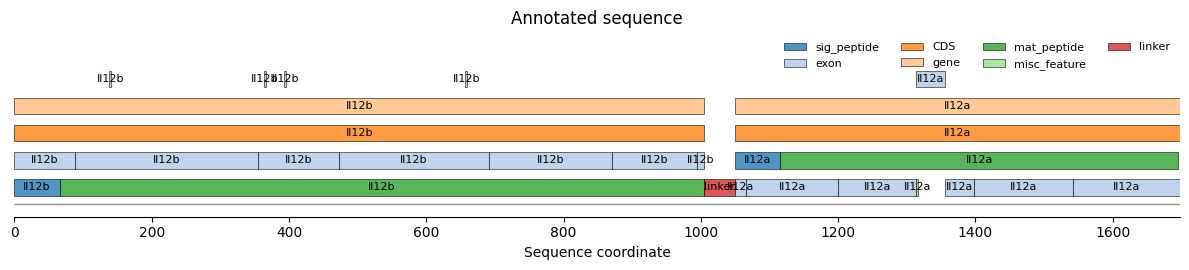

In [34]:
IL12_FUSED.plot_annotations()

## bGH polyadenylation signal

This section adds a bovine growth hormone polyadenylation signal (`bGH polyA`). A polyA signal terminates transcription and supports proper cleavage, polyadenylation, nuclear export, and stability of the mRNA.

In the original construct logic, this part closes the expression cassette after the HSV-TK/P2A/IL-12 coding region. For expression prediction, it gives the assembled sequence a realistic 3-prime transcript-processing element rather than ending abruptly after the coding sequence.


In [35]:
bGH_polyA_record = PlasmidRecord.from_ncbi(ncbi_url='https://www.ncbi.nlm.nih.gov/nuccore/MP663687.1', data_storage='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids', reporter_feature_name='')

In [36]:
bGH_POLY_A = bGH_polyA_record.annotated_sequence()

In [37]:
bGH_POLY_A = AnnotatedSequence(sequence=bGH_POLY_A.sequence,
                               name='bGH_polyA',
                               features=[
                                   Feature(name='bGH_polyA',
                                            start=0,
                                            end=bGH_POLY_A.__len__(),
                                            type='polyA-signal')

                               ])

## Final assembly

This section concatenates the annotated parts into one in-silico AAV transfer cassette:

```text
left AAV ITR + SSE-7 + minimal CMV promoter + Kozak + HSV-TK + P2A + mouse IL-12 fusion + bGH polyA + right AAV ITR
```

This final sequence is the model input for testing whether the super-enhancer confers glioblastoma-selective predicted expression. The expected qualitative behavior is high predicted expression in glioblastoma-relevant conditions and low predicted expression in other cell types, with the glioblastoma-trained model performing best.


In [38]:
resulting_sequence = AnnotatedSequence.concat(
    LEFT_ITR,
    SUPER_ENCHANCER,
    MINIMAL_CMV_PROMOTER,
    KOZAK,
    UL23_TK_CDS,
    P2A,
    IL12_FUSED,
    bGH_POLY_A,
    RIGHT_ITR
)

(<Figure size 1800x400 with 1 Axes>,
 <Axes: title={'center': 'Annotated sequence'}, xlabel='Sequence coordinate'>)

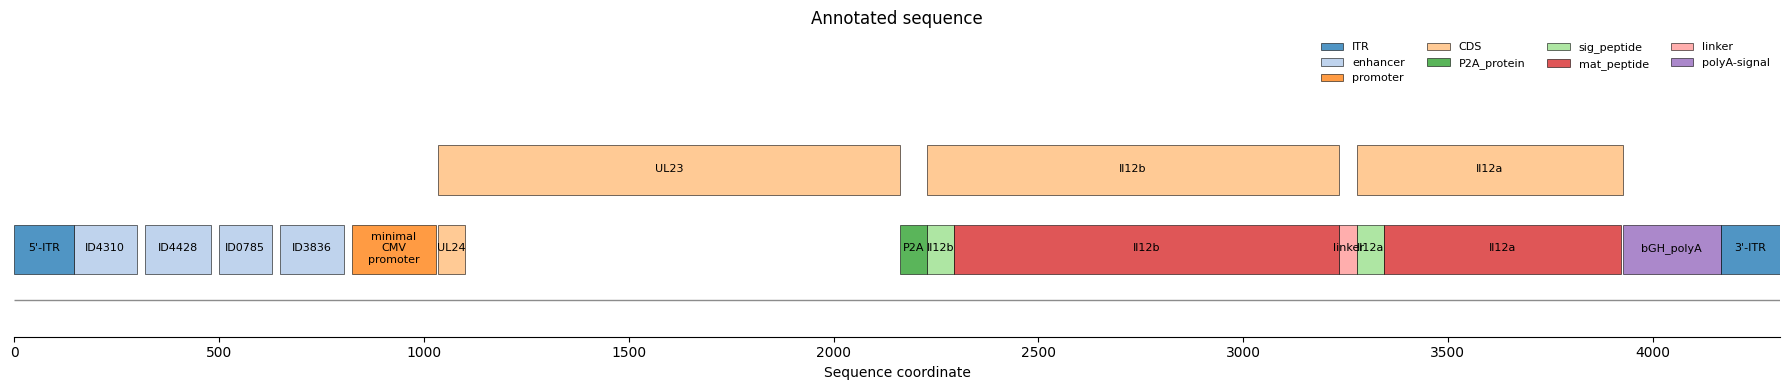

In [39]:
resulting_sequence.plot_annotations(figsize=(18, 4), hide_types=('source', 'gene', 'exon', 'misc_feature'))

Model

In [113]:
model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=1024,
    num_before=511,
    desc_max_seq_len=510,
    token_len_for_fetch=15,
    device=DEVICE,
)

/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/models.py:184: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from AIRI-Institute/moderngena-large


missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_proj.weight
  - layers.25.self_attn.k_proj.weight
  - layers.25.self_attn.v_proj.weight
  - l

In [110]:
lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=['GBM'],
    
)

In [111]:
lookup.items()

dict_items([])

In [65]:
resulting_sequence.features

(Feature(name='source', start=0, end=145, type='source', strand='+', source='genbank', metadata={'location': '1..4675', 'qualifiers': {'organism': 'adeno-associated virus 2', 'mol_type': 'genomic DNA', 'db_xref': 'taxon:10804'}, 'genbank_start': 1, 'genbank_end': 4675}),
 Feature(name="5' inverted terminal repeat", start=0, end=145, type='repeat_region', strand='+', source='genbank', metadata={'location': '1..145', 'qualifiers': {'note': "5' inverted terminal repeat"}, 'genbank_start': 1, 'genbank_end': 145}),
 Feature(name='flip oriented DNA', start=41, end=83, type='misc_feature', strand='+', source='genbank', metadata={'location': '42..83', 'qualifiers': {'note': 'flip oriented DNA'}, 'genbank_start': 42, 'genbank_end': 83}),
 Feature(name='ID4310', start=145, end=299, type='feature', strand=None, source=None, metadata=None),
 Feature(name='ID4428', start=299, end=459, type='feature', strand=None, source=None, metadata=None),
 Feature(name='ID0785', start=459, end=589, type='feature

In [41]:
mouse_heart_rna_seq = {
    "assay_term_name": "RNA-seq",
    "description": "RNA-Seq from oligo-dT primed Total RNA on adult mouse heart tissue",
    "biosample_summary": "Mus musculus strain C57BL/6J heart tissue adult",
    "life_stage_age": "adult",
    "perturbed": False,
    "strand_specificity": "unstranded",
    "genome_annotation": "M21",
    "mapped_run_type": "paired-ended",
    "id": "synthetic_mouse_heart_rnaseq",
    "genome": "mm10",
}

mouse_liver_rna_seq = {
    "assay_term_name": "RNA-seq",
    "description": "RNA-Seq Total RNA on adult mouse liver tissue",
    "biosample_summary": "Mus musculus strain C57BL/6J liver tissue adult",
    "life_stage_age": "adult",
    "perturbed": False,
    "strand_specificity": "unstranded",
    "genome_annotation": "M21",
    "mapped_run_type": "paired-ended",
    "id": "synthetic_mouse_liver_rnaseq",
    "genome": "mm10",
}

mouse_cancer_not_glioblastoma_rna_seq = {
    "assay_term_name": "RNA-seq",
    "description": "RNA-Seq Total RNA on mouse melanoma tumor tissue",
    "biosample_summary": "Mus musculus melanoma tumor tissue adult",
    "life_stage_age": "adult",
    "perturbed": False,
    "strand_specificity": "unstranded",
    "genome_annotation": "M21",
    "mapped_run_type": "paired-ended",
    "id": "synthetic_mouse_melanoma_rnaseq",
    "genome": "mm10",
}

mouse_glioblastoma_rna_seq = {
    "assay_term_name": "RNA-seq",
    "description": "RNA-Seq from Total RNA on mouse glioblastoma tumor tissue",
    "biosample_summary": "Mus musculus glioblastoma tumor tissue adult brain",
    "life_stage_age": "adult",
    "perturbed": False,
    "strand_specificity": "unstranded",
    "genome_annotation": "M21",
    "mapped_run_type": "paired-ended",
    "id": "synthetic_mouse_glioblastoma_rnaseq",
    "genome": "mm10",
}

mouse_glioblastoma_sox2_sox3_rna_seq = {
    "assay_term_name": "RNA-seq",
    "description": "RNA-Seq from Total RNA on mouse glioblastoma tumor tissue expressing Sox2 and Sox3",
    "biosample_summary": "Mus musculus glioblastoma tumor tissue adult brain, Sox2-positive and Sox3-positive",
    "life_stage_age": "adult",
    "perturbed": False,
    "strand_specificity": "unstranded",
    "genome_annotation": "M21",
    "mapped_run_type": "paired-ended",
    "id": "synthetic_mouse_glioblastoma_sox2_sox3_rnaseq",
    "genome": "mm10",
}
mouse_glioblastoma_sox2_sox3_aav_construct_rna_seq = {
    "assay_term_name": "RNA-seq",
    "description": (
        "PolyA RNA-Seq context for mouse glioblastoma tumor cells expressing Sox2 and Sox3. "
        "The input sequence is an in-silico AAV transfer cassette consisting of AAV ITR, "
        "glioblastoma synthetic super-enhancer SSE-7, minimal CMV promoter, Kozak sequence, "
        "HSV-TK CDS, P2A peptide, mouse IL-12 fusion CDS, bGH polyA signal, and AAV ITR."
    ),
    "biosample_summary": (
        "Mus musculus glioblastoma tumor tissue adult brain, Sox2-positive and Sox3-positive; "
        "sequence input is an AAV super-enhancer therapeutic expression cassette"
    ),
    "life_stage_age": "adult",
    "perturbed": False,
    "strand_specificity": "unstranded",
    "genome_annotation": "M21",
    "mapped_run_type": "paired-ended",
    "id": "synthetic_mouse_glioblastoma_sox2_sox3_aav_sse7_construct_rnaseq",
    "genome": "mm10",
}

mouse_sox2_sox3_cell_culture_rna_seq = {
    "assay_term_name": "RNA-seq",
    "description": (
        "RNA-Seq on cultured mouse cells "
        "known to express Sox2 and Sox3"
    ),
    "biosample_summary": (
        "Mus musculus cell culture, Sox2-positive and Sox3-positive"
    ),
    "life_stage_age": "unknown",
    "perturbed": False,
    "strand_specificity": "unstranded",
    "genome_annotation": "M21",
    "mapped_run_type": "paired-ended",
    "id": "synthetic_mouse_sox2_sox3_cell_culture_rnaseq",
    "genome": "mm10",
}

In [77]:
prediction = model.predict_sequence(sequence=resulting_sequence,
                        center=949,
                        condition=mouse_heart_rna_seq)

In [131]:
prediction.expression

-0.00347900390625

In [79]:
prediction = model.predict_sequence(sequence=resulting_sequence,
                        center=949,
                        condition=mouse_liver_rna_seq)

In [137]:
prediction.expression

0.032958984375

In [138]:
prediction = model.predict_sequence(sequence=resulting_sequence,
                        center=949,
                        condition=mouse_cancer_not_glioblastoma_rna_seq)

In [139]:
prediction.expression

0.018798828125

In [73]:
prediction = model.predict_sequence(sequence=resulting_sequence,
                        center=949,
                        condition=mouse_glioblastoma_rna_seq)

In [53]:
resulting_sequence.__len__()

4311

In [71]:
prediction.track().tokens.__len__()

735

In [74]:
prediction.track().tokens

[{'token_id': 314,
  'token': 'TTGGCC',
  'length': 6,
  'genomic_side': 'left',
  'input_position': 1,
  'start': 0,
  'end': 6,
  'center': 3.0,
  'feature_names': ["5'-ITR"],
  'source': None},
 {'token_id': 871,
  'token': 'ACTCCC',
  'length': 6,
  'genomic_side': 'left',
  'input_position': 2,
  'start': 6,
  'end': 12,
  'center': 9.0,
  'feature_names': ["5'-ITR"],
  'source': None},
 {'token_id': 1429,
  'token': 'TCTCTGC',
  'length': 7,
  'genomic_side': 'left',
  'input_position': 3,
  'start': 12,
  'end': 19,
  'center': 15.5,
  'feature_names': ["5'-ITR"],
  'source': None},
 {'token_id': 836,
  'token': 'GCGC',
  'length': 4,
  'genomic_side': 'left',
  'input_position': 4,
  'start': 19,
  'end': 23,
  'center': 21.0,
  'feature_names': ["5'-ITR"],
  'source': None},
 {'token_id': 341,
  'token': 'TCGC',
  'length': 4,
  'genomic_side': 'left',
  'input_position': 5,
  'start': 23,
  'end': 27,
  'center': 25.0,
  'feature_names': ["5'-ITR"],
  'source': None},
 {'toke

In [43]:
import matplotlib.pyplot as plt

(<Figure size 1800x500 with 2 Axes>,
 <Axes: title={'center': 'track'}, xlabel='Sequence coordinate', ylabel='track'>)

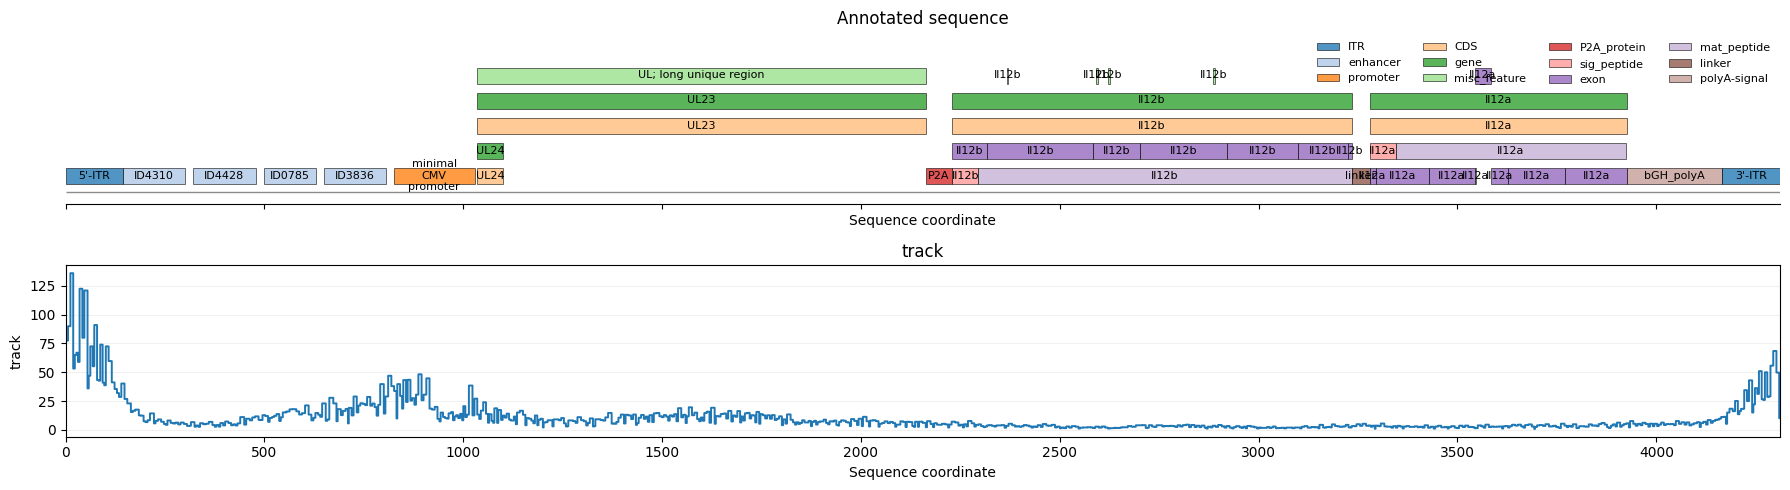

In [92]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(18, 5), sharex=True)
resulting_sequence.plot_annotations(ax=axs[0])
prediction.track().plot(ax=axs[1], color_by_sign=False)

In [149]:
prediction.expression

0.01171875

In [142]:
prediction = model.predict_sequence(sequence=resulting_sequence,
                        center=949,
                        condition=mouse_glioblastoma_sox2_sox3_rna_seq)

In [143]:
prediction.expression

0.01153564453125

In [81]:
prediction = model.predict_sequence(sequence=resulting_sequence,
                        center=949,
                        condition=mouse_glioblastoma_sox2_sox3_aav_construct_rna_seq)

In [145]:
prediction.expression

0.02490234375

In [146]:
prediction = model.predict_sequence(sequence=resulting_sequence,
                        center=949,
                        condition=mouse_sox2_sox3_cell_culture_rna_seq)

In [147]:
prediction.expression

0.0361328125

In [83]:
prediction = model.predict_sequence(sequence=resulting_sequence,
                        center=949,
                        condition={'description': 'mouse cells'})

In [84]:
prediction.expression

6.5625

In [87]:
prediction = model.predict_sequence(sequence=resulting_sequence,
                        center=949,
                        condition={'description': 'mouse cells from heart tissue, ATAC-seq'})

In [107]:
prediction.expression

14.125

In [108]:
prediction = model.predict_sequence(sequence=resulting_sequence,
                        center=949,
                        condition={'description': 'mouse cells from liver tissue'})

In [109]:
prediction.expression

22.25

In [79]:
prediction = model.predict_sequence(sequence=resulting_sequence,
                        center=949,
                        condition={'description': 'mouse cells from brain tissue'})

In [80]:
prediction.expression

8.625

In [91]:
prediction = model.predict_sequence(sequence=resulting_sequence,
                        center=949,
                        condition={'description': 'mouse cells expressing SOX2 and SOX9, ATAC-seq'})

In [76]:
prediction.expression

2.703125

In [131]:
lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=['IMR-90'],
)

In [132]:
lookup.items()

dict_items([('IMR-90', {'assay_term_name': 'polyA plus RNA-seq', 'description': 'RNA-seq on human IMR90 whole cell long polyA+ RNA', 'biosample_summary': 'Homo sapiens IMR-90', 'life_stage_age': 'embryonic 16 weeks', 'perturbed': False, 'strand_specificity': 'reverse', 'genome_annotation': 'V29', 'mapped_run_type': 'paired-ended', 'id': 'ENCFF768XGT', 'genome': 'GRCh38'})])

In [135]:
import numpy as np

In [163]:
genome = Genome(
    fasta_path=GENOME_FASTA,
    annotation=GENOME_ANNOTATION,
)

In [ ]:
sequence = genome.sequence_around(center=np.mean([120523906, 120524644]).astype(int), chrom='chr1', strand='+', size=10_000)

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'Annotated sequence'}, xlabel='Sequence coordinate'>)

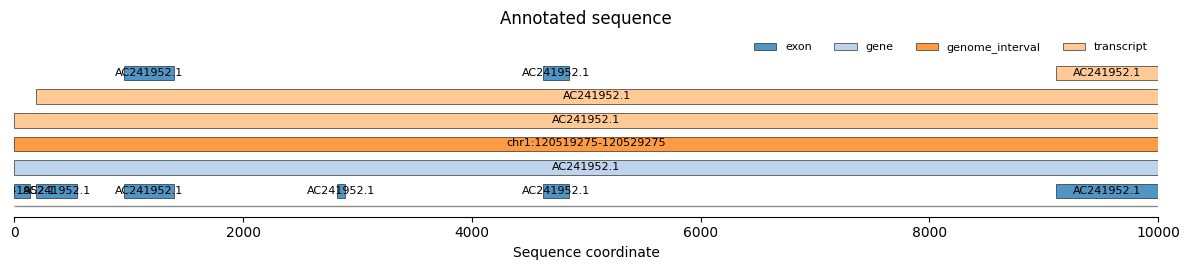

In [165]:
sequence.plot_annotations()

In [154]:
prediction = model.predict_sequence(sequence=sequence, center=5000, condition=lookup['IMR-90'])

In [168]:
prediction.track().tokens

[{'token_id': 659,
  'token': 'TGCTGG',
  'length': 6,
  'genomic_side': 'left',
  'input_position': 1,
  'start': 1874,
  'end': 1880,
  'center': 1877.0,
  'feature_names': ['chr3:181706924-181716924',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT',
   'SOX2-OT'],
  'source': None},
 {'token_id': 73,
  'token': 'ATTG',
  'length': 4,
  'genomic_side': 'left'

(<Figure size 1200x300 with 1 Axes>,
 <Axes: title={'center': 'track'}, xlabel='Sequence coordinate', ylabel='track'>)

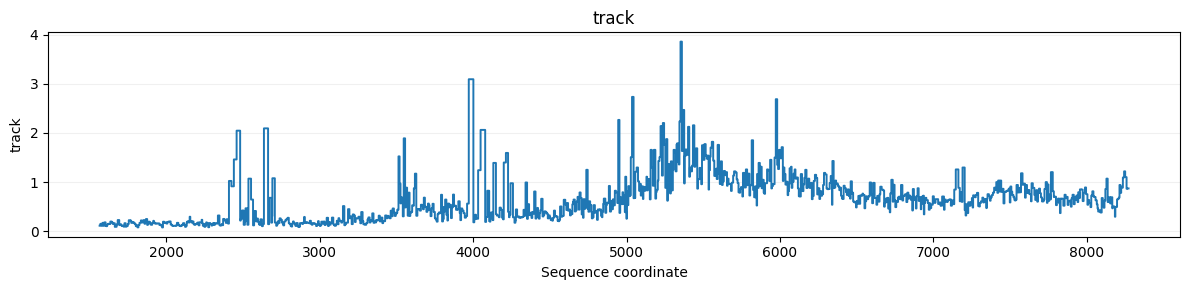

In [155]:
prediction.track().plot(color_by_sign=False)

(<Figure size 1800x500 with 2 Axes>,
 <Axes: title={'center': 'track'}, xlabel='Sequence coordinate', ylabel='track'>)

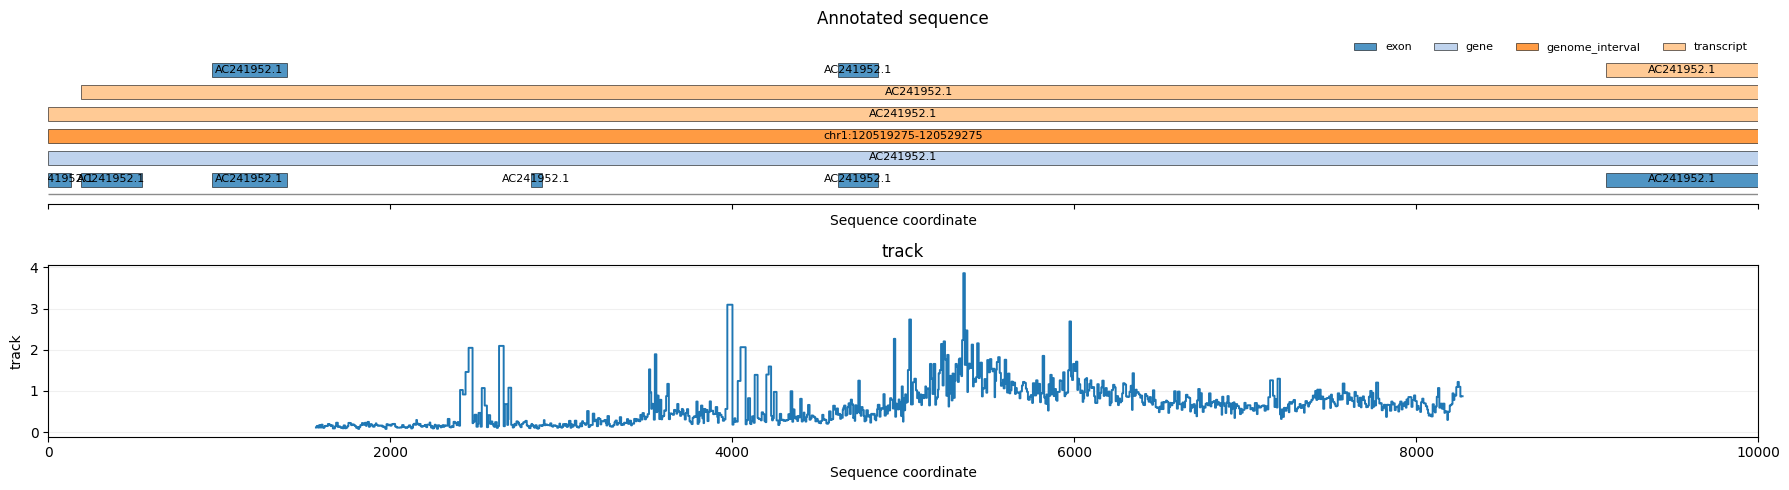

In [156]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0])
prediction.track().plot(ax=axs[1], color_by_sign=False)

**SOX2**

In [157]:
sequence = genome.sequence_around(center=181711924, chrom='chr3', strand='+', size=10_000)

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'Annotated sequence'}, xlabel='Sequence coordinate'>)

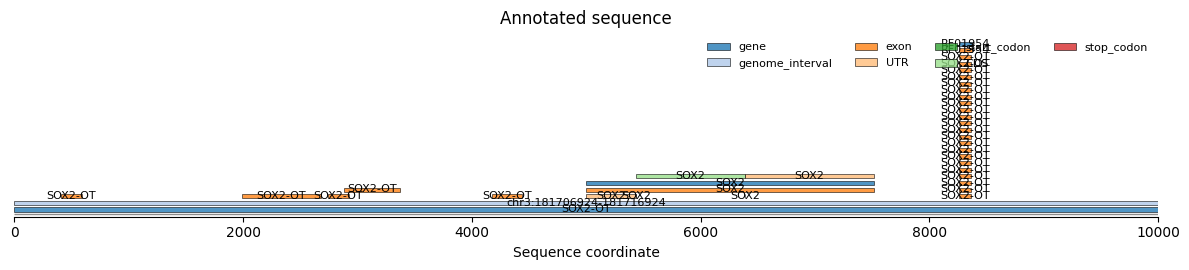

In [158]:
sequence.plot_annotations(hide_types=('source', 'transcript'))

In [159]:
prediction = model.predict_sequence(sequence=sequence, center=5000, condition=lookup['IMR-90'])

(<Figure size 1200x300 with 1 Axes>,
 <Axes: title={'center': 'track'}, xlabel='Sequence coordinate', ylabel='track'>)

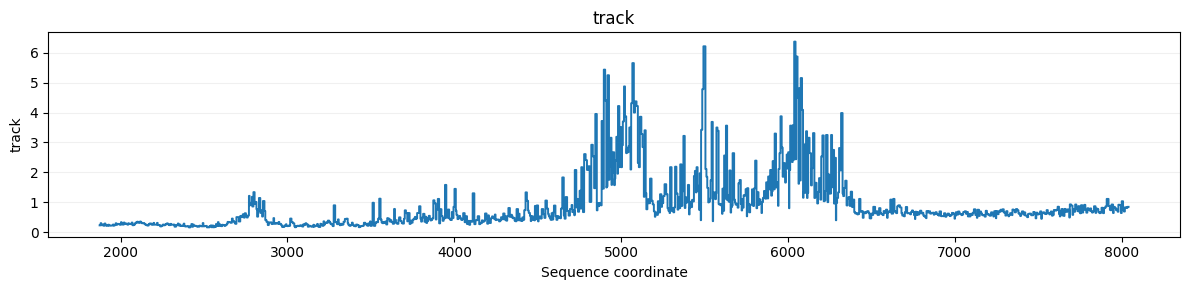

In [160]:
prediction.track().plot(color_by_sign=False)

(<Figure size 1800x500 with 2 Axes>,
 <Axes: title={'center': 'track'}, xlabel='Sequence coordinate', ylabel='track'>)

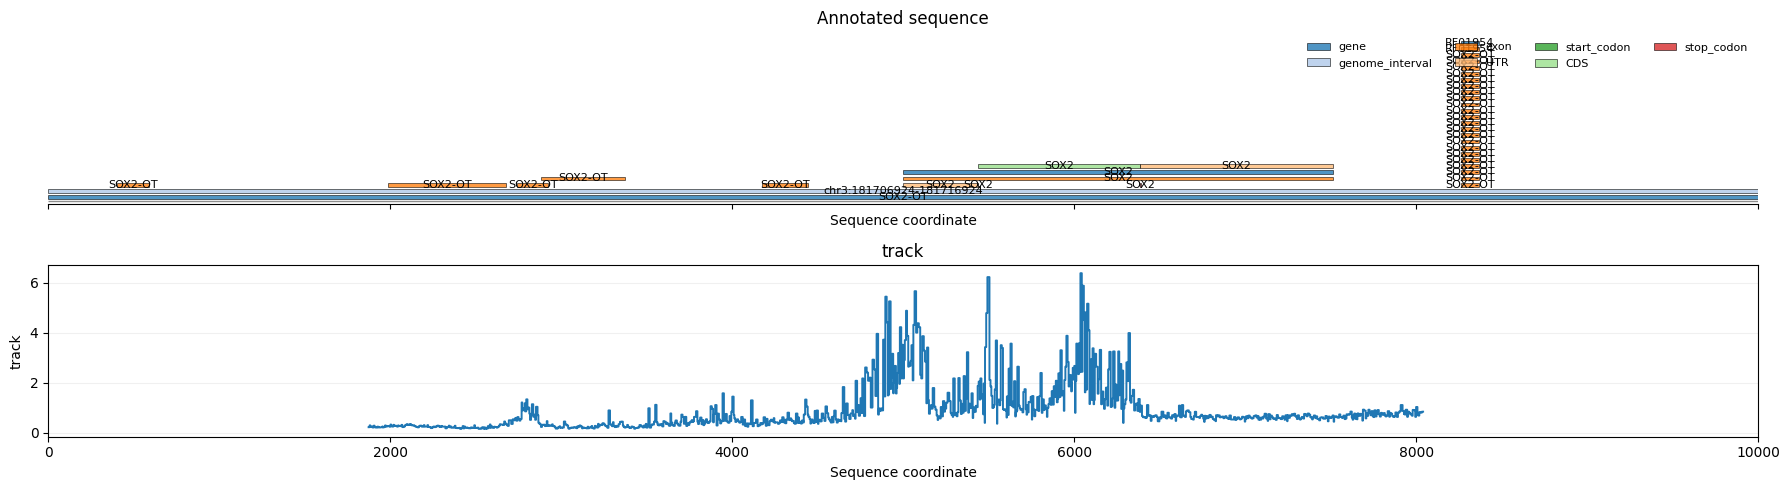

In [161]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript'))
prediction.track().plot(ax=axs[1], color_by_sign=False)

In [166]:
prediction.track()

TrackPrediction(name='track', values=[0.2236328125, 0.296875, 0.2294921875, 0.25390625, 0.2119140625, 0.28515625, 0.2236328125, 0.208984375, 0.2451171875, 0.2138671875, 0.21875, 0.2216796875, 0.251953125, 0.21484375, 0.2392578125, 0.29296875, 0.24609375, 0.2734375, 0.271484375, 0.2431640625, 0.330078125, 0.28125, 0.2490234375, 0.318359375, 0.271484375, 0.28515625, 0.2734375, 0.2470703125, 0.294921875, 0.26953125, 0.265625, 0.31640625, 0.228515625, 0.25390625, 0.302734375, 0.32421875, 0.345703125, 0.310546875, 0.318359375, 0.3515625, 0.318359375, 0.294921875, 0.30078125, 0.27734375, 0.2490234375, 0.2275390625, 0.2177734375, 0.263671875, 0.287109375, 0.28515625, 0.24609375, 0.251953125, 0.306640625, 0.248046875, 0.2470703125, 0.306640625, 0.232421875, 0.2373046875, 0.23046875, 0.1884765625, 0.2158203125, 0.25, 0.2265625, 0.251953125, 0.259765625, 0.287109375, 0.283203125, 0.251953125, 0.2314453125, 0.2734375, 0.2451171875, 0.24609375, 0.2490234375, 0.1796875, 0.2314453125, 0.2275390625, 